In [1]:
#import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
#load dataset

data = pd.read_csv(r"C:\Users\hassa\Downloads\Data Science\sp500_comprehensive\sp500_master_50years.csv")

In [3]:
#create a copy of the dataset

df = data.copy()

In [5]:
#view top 5 rows of dataset

df.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock splits,Ticker,Name,Sector,Industry,Daily_return,Monthly_return,Sma200,Sma50,Volatility,Weekly_return
0,1970-01-02 00:00:00-05:00,0.274696,0.290567,0.274696,0.290567,634838,0.0,0.0,BA,The Boeing Company,Industrials,Aerospace & Defense,NaN,NaN,NaN,NaN,NaN,NaN
1,1970-01-02 00:00:00-05:00,1.258020,1.258020,1.224720,1.228419,276000,0.0,0.0,CAT,Caterpillar Inc.,Industrials,Farm & Heavy Construction Machinery,NaN,NaN,NaN,NaN,NaN,NaN
2,1970-01-02 00:00:00-05:00,0.399793,0.408590,0.399793,0.408590,526400,0.0,0.0,CVX,Chevron Corporation,Energy,Oil & Gas Integrated,NaN,NaN,NaN,NaN,NaN,NaN
3,1970-01-02 00:00:00-05:00,0.447662,0.448497,0.444321,0.444321,1109377,0.0,0.0,DIS,The Walt Disney Company,Communication Services,Entertainment,NaN,NaN,NaN,NaN,NaN,NaN
4,1970-01-02 00:00:00-05:00,0.637771,0.660433,0.637771,0.650721,60096,0.0,0.0,HON,Honeywell International Inc.,Industrials,Conglomerates,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#view the shape of the dataset

df.shape

(1014000, 18)

In [7]:
#check out the columns in the dataset

df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock splits', 'Ticker', 'Name', 'Sector', 'Industry', 'Daily_return',
       'Monthly_return', 'Sma200', 'Sma50', 'Volatility', 'Weekly_return'],
      dtype='object')

In [8]:
#check the data types in the dataset

df.dtypes

Date               object
Open              float64
High              float64
Low               float64
Close             float64
Volume              int64
Dividends         float64
Stock splits      float64
Ticker             object
Name               object
Sector             object
Industry           object
Daily_return      float64
Monthly_return    float64
Sma200            float64
Sma50             float64
Volatility        float64
Weekly_return     float64
dtype: object

In [9]:
#check the summary of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014000 entries, 0 to 1013999
Data columns (total 18 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Date            1014000 non-null  object 
 1   Open            1014000 non-null  float64
 2   High            1014000 non-null  float64
 3   Low             1014000 non-null  float64
 4   Close           1014000 non-null  float64
 5   Volume          1014000 non-null  int64  
 6   Dividends       1014000 non-null  float64
 7   Stock splits    1014000 non-null  float64
 8   Ticker          1014000 non-null  object 
 9   Name            1014000 non-null  object 
 10  Sector          1014000 non-null  object 
 11  Industry        1014000 non-null  object 
 12  Daily_return    1013902 non-null  float64
 13  Monthly_return  1011960 non-null  float64
 14  Sma200          994286 non-null   float64
 15  Sma50           1009136 non-null  float64
 16  Volatility      1011087 non-null  fl

In [10]:
#Checking for null values

df.isnull().sum()

Date                  0
Open                  0
High                  0
Low                   0
Close                 0
Volume                0
Dividends             0
Stock splits          0
Ticker                0
Name                  0
Sector                0
Industry              0
Daily_return         98
Monthly_return     2040
Sma200            19714
Sma50              4864
Volatility         2913
Weekly_return       486
dtype: int64

In [11]:
#drop columns with missing values

df = df.drop(columns = ['Daily_return','Monthly_return', 'Sma200', 'Sma50', 'Volatility', 'Weekly_return'], axis=1)
df.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock splits,Ticker,Name,Sector,Industry
0,1970-01-02 00:00:00-05:00,0.274696,0.290567,0.274696,0.290567,634838,0.0,0.0,BA,The Boeing Company,Industrials,Aerospace & Defense
1,1970-01-02 00:00:00-05:00,1.258020,1.258020,1.224720,1.228419,276000,0.0,0.0,CAT,Caterpillar Inc.,Industrials,Farm & Heavy Construction Machinery
2,1970-01-02 00:00:00-05:00,0.399793,0.408590,0.399793,0.408590,526400,0.0,0.0,CVX,Chevron Corporation,Energy,Oil & Gas Integrated
3,1970-01-02 00:00:00-05:00,0.447662,0.448497,0.444321,0.444321,1109377,0.0,0.0,DIS,The Walt Disney Company,Communication Services,Entertainment
4,1970-01-02 00:00:00-05:00,0.637771,0.660433,0.637771,0.650721,60096,0.0,0.0,HON,Honeywell International Inc.,Industrials,Conglomerates


In [12]:
# Ensuring Date is datetime and sorting dataset

df['Date'] = pd.to_datetime(df['Date'], utc = True)
df = df.sort_values(['Ticker', 'Date'])

Monthly Seasonality Analysis: Identify recurring monthly patterns in returns and volatility.

In [13]:
#create returns

df['Returns'] = np.log(df['Close'] / df.groupby('Ticker')['Close'].shift(1))

# Drop missing values from returns
df = df.dropna()

In [14]:
df.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock splits,Ticker,Name,Sector,Industry,Returns
80958,1980-12-15 05:00:00+00:00,0.093597,0.093597,0.093169,0.093169,175884800,0.0,0.0,AAPL,Apple Inc.,Technology,Consumer Electronics,-0.053580
81008,1980-12-16 05:00:00+00:00,0.086758,0.086758,0.086331,0.086331,105728000,0.0,0.0,AAPL,Apple Inc.,Technology,Consumer Electronics,-0.076231
81058,1980-12-17 05:00:00+00:00,0.088468,0.088895,0.088468,0.088468,86441600,0.0,0.0,AAPL,Apple Inc.,Technology,Consumer Electronics,0.024450
81108,1980-12-18 05:00:00+00:00,0.091033,0.091460,0.091033,0.091033,73449600,0.0,0.0,AAPL,Apple Inc.,Technology,Consumer Electronics,0.028580
81158,1980-12-19 05:00:00+00:00,0.096588,0.097015,0.096588,0.096588,48630400,0.0,0.0,AAPL,Apple Inc.,Technology,Consumer Electronics,0.059239


In [15]:
#extracting year and month

df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Year'] = df['Date'].dt.year

In [16]:
#create a 30 days rolling window volatility column

df['30_days_vol'] = df.groupby('Ticker')['Returns'].rolling(30).std().reset_index(0,drop=True)

In [17]:
#create a 60 days rolling window volatility column

df['60_days_vol'] = df.groupby('Ticker')['Returns'].rolling(60).std().reset_index(0,drop=True)

#create a 252 days rolling window volatility column
df['252_days_vol'] = df.groupby('Ticker')['Returns'].rolling(252).std().reset_index(0,drop=True)

Monthly data analysis

In [18]:
#Extract the summary for the monthly returns

monthly_returns = df.groupby('Month_Name')['Returns'].agg(
    mean_return='mean',
    std_return='std')

In [19]:
# Reorder months correctly
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_returns = monthly_returns.reindex(month_order)
print("Monthly Returns Summary:")
print(monthly_returns)

Monthly Returns Summary:
            mean_return  std_return
Month_Name                         
January        0.000648    0.022182
February       0.000329    0.020949
March          0.000686    0.023467
April          0.000799    0.022500
May            0.000708    0.019792
June           0.000143    0.019038
July           0.000590    0.020615
August         0.000200    0.019847
September     -0.000299    0.021064
October        0.000517    0.025525
November       0.001236    0.022343
December       0.000751    0.019730


In [20]:
#Calculate monthly Volatility

monthly_volatility = df.groupby('Month_Name')['Returns'].std().sort_values()

print("\nMonthly Volatility:")
print(monthly_volatility)


Monthly Volatility:
Month_Name
June         0.019038
December     0.019730
May          0.019792
August       0.019847
July         0.020615
February     0.020949
September    0.021064
January      0.022182
November     0.022343
April        0.022500
March        0.023467
October      0.025525
Name: Returns, dtype: float64


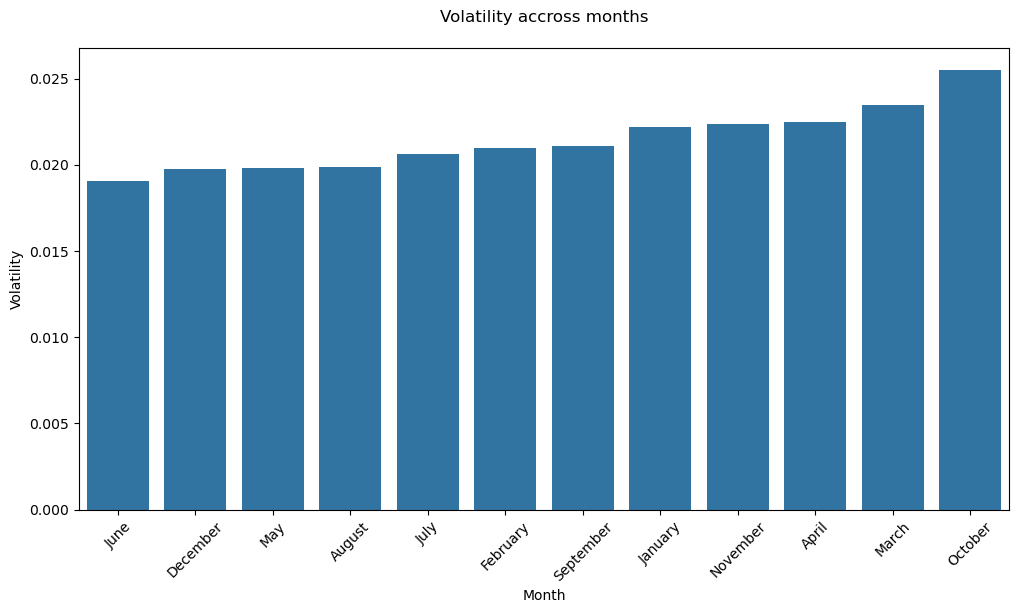

In [21]:
#Lets visualize monthly Volatility

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_volatility.index, y=monthly_volatility.values)
plt.xticks(rotation=45)
plt.title("Volatility accross months\n")
plt.ylabel("Volatility")
plt.xlabel("Month")
plt.show()

In [22]:
#Calculate monthly Returns

monthly_returns = df.groupby('Month_Name')['Returns'].mean().sort_values()

print("\nMonthly Returns:")
print(monthly_returns)


Monthly Returns:
Month_Name
September   -0.000299
June         0.000143
August       0.000200
February     0.000329
October      0.000517
July         0.000590
January      0.000648
March        0.000686
May          0.000708
December     0.000751
April        0.000799
November     0.001236
Name: Returns, dtype: float64


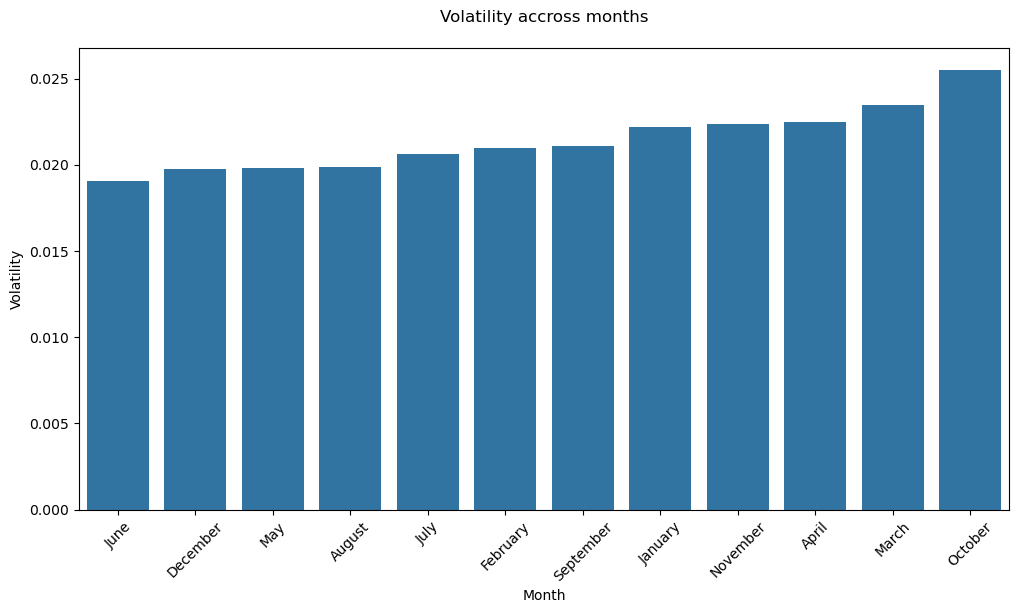

In [23]:
#Lets visualize monthly volatility

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_volatility.index, y=monthly_volatility.values)
plt.xticks(rotation=45)
plt.title("Volatility accross months\n")
plt.ylabel("Volatility")
plt.xlabel("Month")
plt.show()

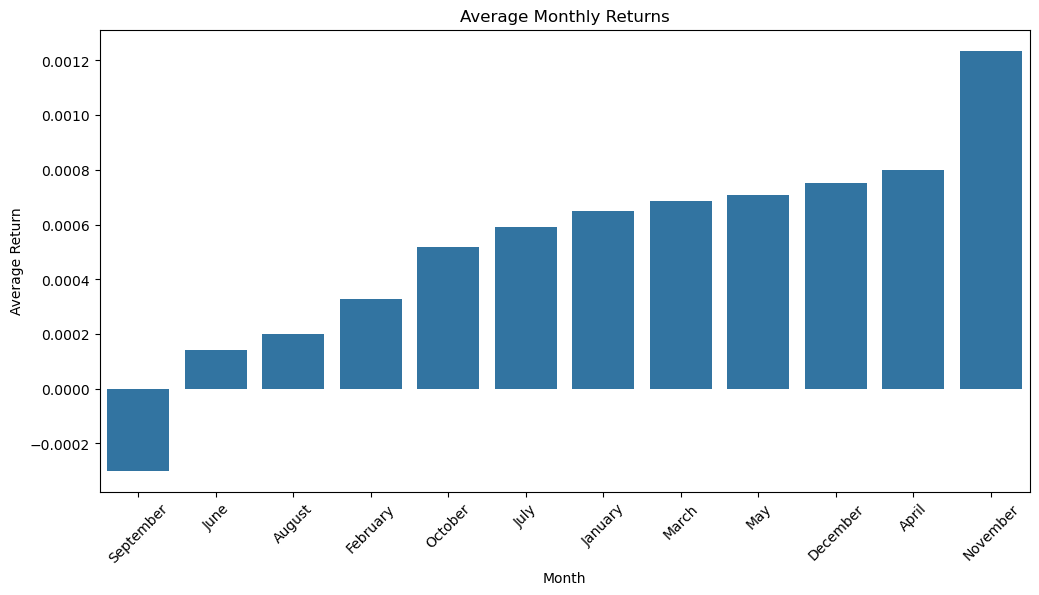

In [24]:
#Lets visualize average Returns by Month

plt.figure(figsize=(12,6))
sns.barplot(x = monthly_returns.index, y = monthly_returns.values)
plt.xticks(rotation=45)
plt.title("Average Monthly Returns")
plt.ylabel("Average Return")
plt.xlabel("Month")
plt.show()

Yearly Performance Trends: Evaluate annual returns and volatility trends

In [25]:
# Estimate mean and volatility average yearly
yearly_performance = df.groupby('Year')['Returns'].agg(
    mean_return='mean',
    volatility='std'
)

print(yearly_performance.head())

      mean_return  volatility
Year                         
1970    -0.000219    0.022503
1971     0.001124    0.019133
1972     0.001171    0.015869
1973    -0.000982    0.022956
1974    -0.001285    0.027421


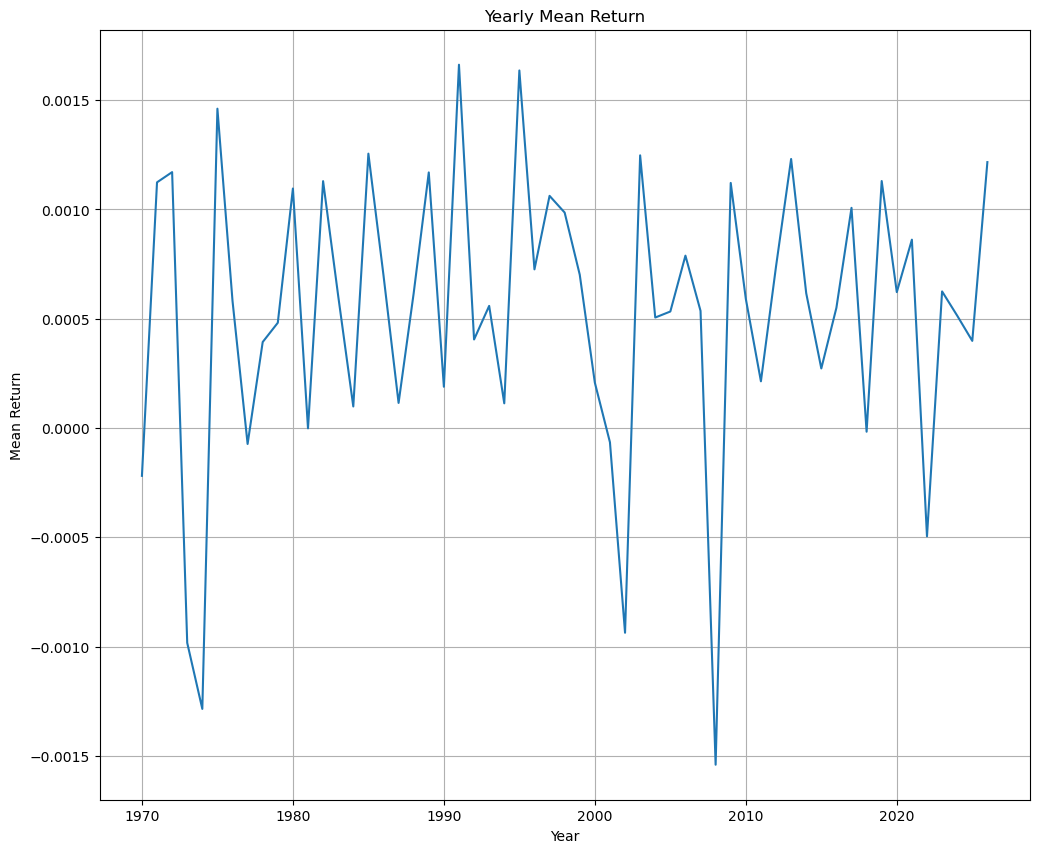

In [26]:
# Plot annual return

plt.figure(figsize=(12, 10))
plt.plot(yearly_performance['mean_return'])
plt.title('Yearly Mean Return')
plt.grid()
plt.xlabel('Year')
plt.ylabel('Mean Return')
plt.show()

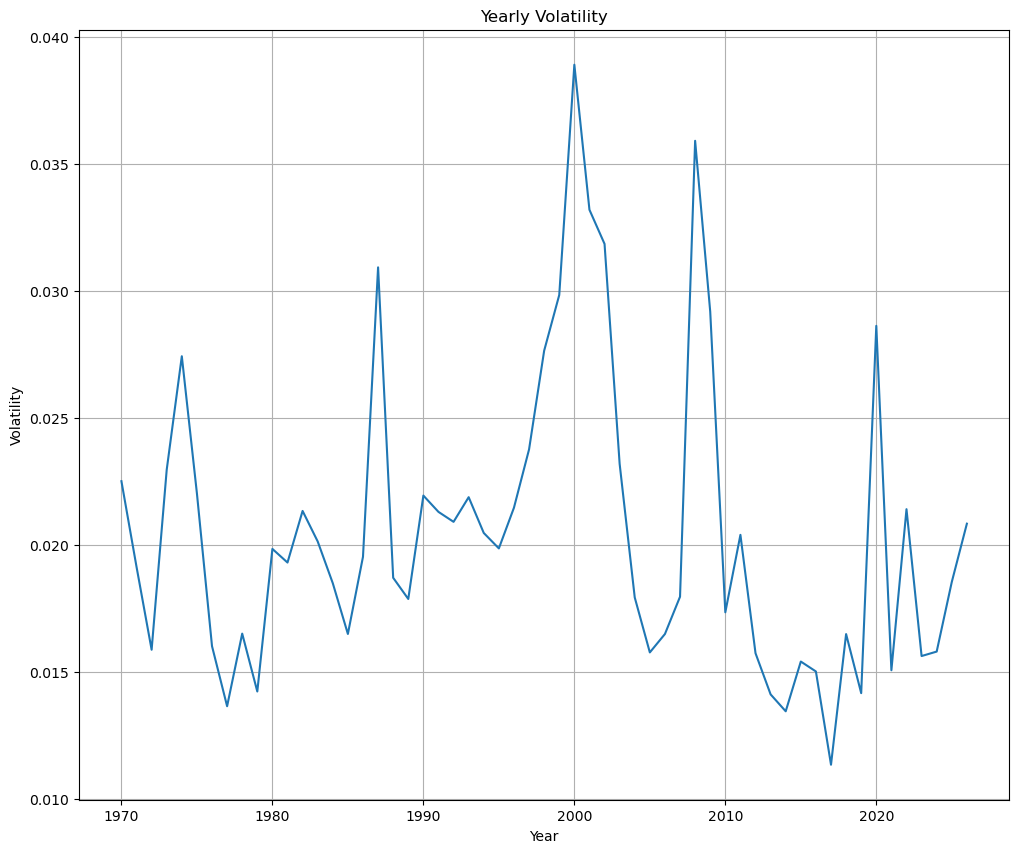

In [27]:
#plot yearly volatility
plt.figure(figsize=(12, 10))
plt.plot(yearly_performance['volatility'])
plt.title('Yearly Volatility')
plt.grid()
plt.xlabel('Year')
plt.ylabel('Volatility')
plt.show()

Monthly vs Yearly Gross Analysis: See how monthly patterns vary across years.

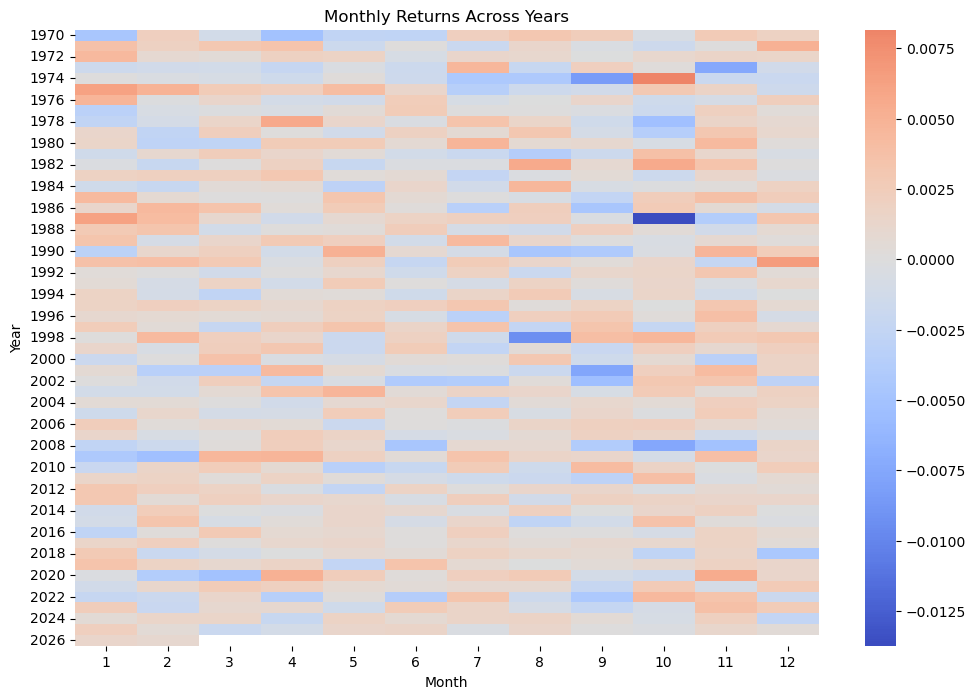

In [28]:
# Create pivot table: Year vs Month average returns
monthly_yearly_pivot = df.pivot_table(
   values='Returns',
    index='Year',
    columns='Month',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))
sns.heatmap(monthly_yearly_pivot, cmap='coolwarm', center=0)
plt.title("Monthly Returns Across Years")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

Sector-Level Summary Statistics

In [29]:
sector_summary = df.groupby('Sector')['Returns'].agg(
    mean_return='mean',
    volatility='std').reset_index()

print(sector_summary)

                    Sector  mean_return  volatility
0          Basic Materials     0.000481    0.019984
1   Communication Services     0.000542    0.021437
2        Consumer Cyclical     0.000655    0.024569
3       Consumer Defensive     0.000491    0.016581
4                   Energy     0.000459    0.015860
5       Financial Services     0.000472    0.021091
6               Healthcare     0.000529    0.022265
7              Industrials     0.000466    0.019324
8              Real Estate     0.000326    0.029707
9               Technology     0.000660    0.026048
10               Utilities     0.000459    0.013312


Monthly Seasonality by Sector

In [30]:
sector_monthly = df.groupby(['Sector', 'Month_Name'])['Returns'].mean().unstack()
sector_monthly = sector_monthly[month_order]

print(sector_monthly.head())

Month_Name               January  February     March     April       May  \
Sector                                                                     
Basic Materials         0.000195  0.000489  0.001272  0.001123  0.000403   
Communication Services  0.001456  0.000206  0.000408  0.000676  0.000969   
Consumer Cyclical       0.000532  0.000655  0.001414  0.000937  0.000779   
Consumer Defensive      0.000268  0.000407  0.000963  0.000517  0.000700   
Energy                  0.000298  0.000483  0.000737  0.001290  0.000238   

Month_Name                  June      July    August  September   October  \
Sector                                                                      
Basic Materials        -0.000181  0.000585  0.000344  -0.000530 -0.000029   
Communication Services  0.000208  0.000352 -0.000231  -0.000030  0.000681   
Consumer Cyclical       0.000220  0.000325  0.000349  -0.000099  0.000531   
Consumer Defensive      0.000367  0.000686  0.000097  -0.000267  0.000807   
Energ

Yearly Performance by Sector

In [31]:
sector_yearly = df.groupby(['Sector', 'Year'])['Returns'].agg(
    mean_return='mean',
    volatility='std'
)

print(sector_yearly.head())

                      mean_return  volatility
Sector          Year                         
Basic Materials 1980     0.001058    0.022203
                1981     0.000058    0.022322
                1982     0.001189    0.021398
                1983     0.000417    0.020672
                1984    -0.000299    0.018804


Compare sectors: which sector perform best

In [32]:
#determine which sector has highest average returns

sector_performance = df.groupby('Sector')['Returns'].mean().sort_values(ascending=False)
print(sector_performance)

Sector
Technology                0.000660
Consumer Cyclical         0.000655
Communication Services    0.000542
Healthcare                0.000529
Consumer Defensive        0.000491
Basic Materials           0.000481
Financial Services        0.000472
Industrials               0.000466
Energy                    0.000459
Utilities                 0.000459
Real Estate               0.000326
Name: Returns, dtype: float64


Most risky sector

In [33]:
#determine the most risky sector. calculate volatility. the sector with highest volatility is most risky

sector_risk = df.groupby('Sector')['Returns'].std().sort_values(ascending=False)
print(sector_risk)

Sector
Real Estate               0.029707
Technology                0.026048
Consumer Cyclical         0.024569
Healthcare                0.022265
Communication Services    0.021437
Financial Services        0.021091
Basic Materials           0.019984
Industrials               0.019324
Consumer Defensive        0.016581
Energy                    0.015860
Utilities                 0.013312
Name: Returns, dtype: float64


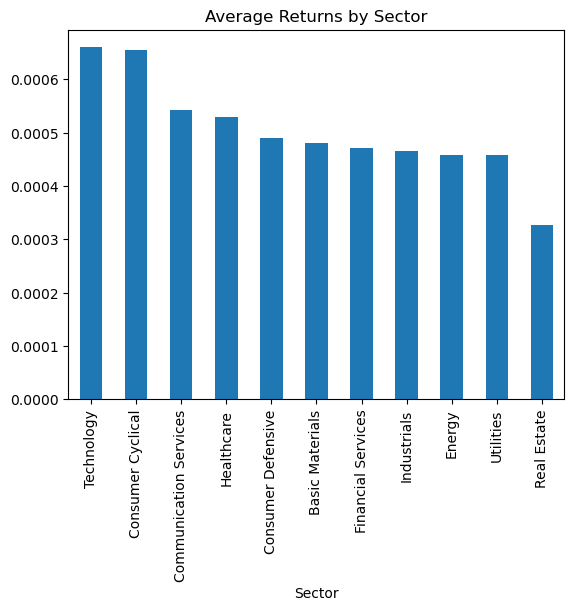

In [34]:
#Sector Returns Comparison

sector_performance.plot(kind='bar', title='Average Returns by Sector')
plt.show()

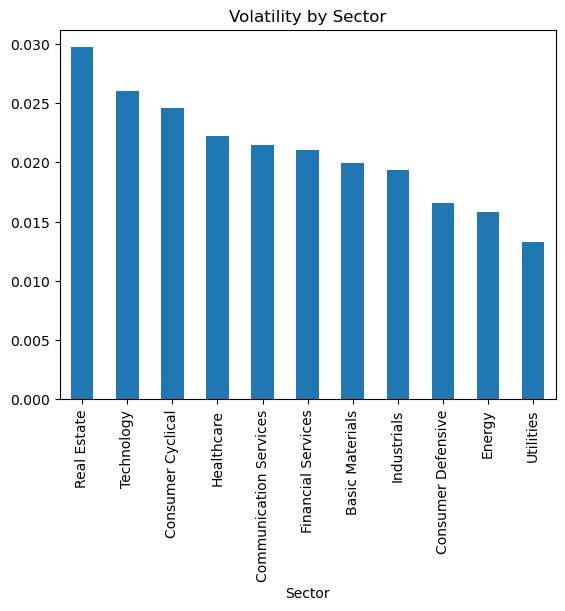

In [35]:
#Sector Volatility Comparison

sector_risk.plot(kind='bar', title='Volatility by Sector')
plt.show()

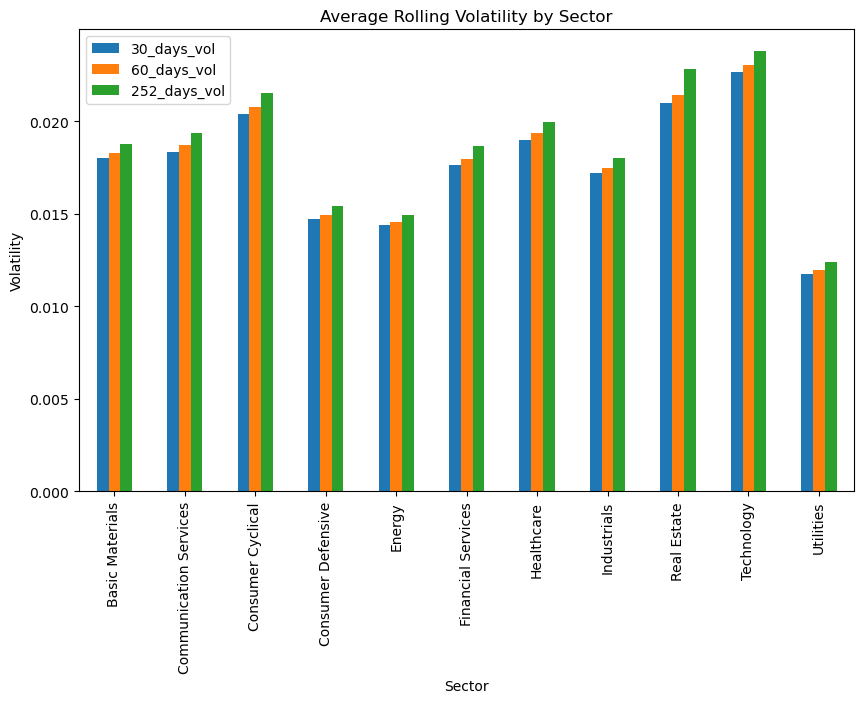

In [36]:
#average rolling volatilty by sector


sector_df = df.dropna(subset=['30_days_vol','60_days_vol','252_days_vol'])
sector_vol = sector_df.groupby('Sector')[['30_days_vol','60_days_vol','252_days_vol']].mean()
sector_vol.plot(kind='bar', figsize=(10,6))
plt.title('Average Rolling Volatility by Sector')
plt.ylabel('Volatility')
plt.show()

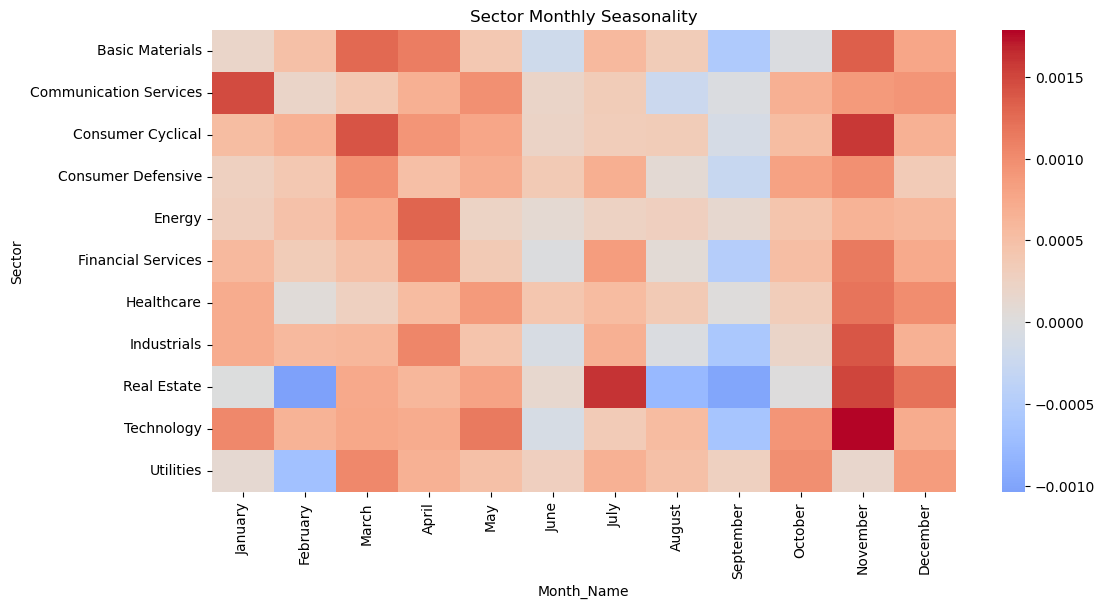

In [37]:
#Heatmap (Sector vs Month)

plt.figure(figsize=(12,6))
sns.heatmap(sector_monthly, cmap='coolwarm', center=0)
plt.title("Sector Monthly Seasonality")
plt.show()

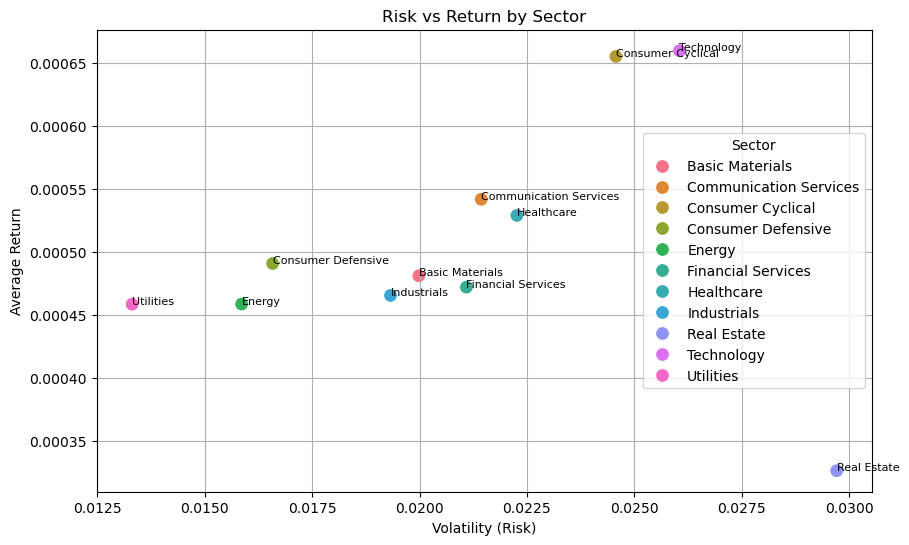

In [38]:
#Sector level risk versus returns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data= sector_summary,
    x='volatility',
    y='mean_return',
    hue='Sector',
    s=100
)

for i in range(len(sector_summary)):
    plt.text(
        sector_summary['volatility'][i],
        sector_summary['mean_return'][i],
        sector_summary['Sector'][i],
        fontsize=8
    )

plt.xlabel('Volatility (Risk)')
plt.ylabel('Average Return')
plt.title('Risk vs Return by Sector')
plt.grid(True)

plt.show()

Industry-Level Summary Statistics

In [39]:
industry_summary = df.groupby('Industry')['Returns'].agg(
    mean_return='mean',
    volatility='std').reset_index()

print(industry_summary.head())

              Industry  mean_return  volatility
0  Aerospace & Defense     0.000493    0.020585
1       Apparel Retail     0.000622    0.021813
2     Asset Management     0.000733    0.021086
3  Banks - Diversified     0.000325    0.023608
4     Banks - Regional     0.000459    0.018896


In [40]:
#Monthly Seasonality by Industry

industry_monthly = df.groupby(['Industry', 'Month_Name'])['Returns'].mean().unstack()
industry_monthly = industry_monthly[month_order]

print(industry_monthly.head())

Month_Name            January  February     March     April       May  \
Industry                                                                
Aerospace & Defense  0.001174  0.000623  0.000297  0.001124  0.000818   
Apparel Retail       0.000016  0.001550  0.001543 -0.000193  0.001205   
Asset Management     0.000707 -0.000179  0.000818  0.000313  0.000354   
Banks - Diversified  0.001037  0.000026  0.000592  0.001109  0.000351   
Banks - Regional     0.000436  0.000343  0.000067  0.001216  0.000442   

Month_Name               June      July    August  September   October  \
Industry                                                                 
Aerospace & Defense -0.000063  0.000848  0.000196  -0.000414 -0.000448   
Apparel Retail      -0.000250  0.000783  0.001184  -0.000705 -0.000108   
Asset Management     0.000003  0.001810  0.000259   0.000159  0.001142   
Banks - Diversified -0.000108  0.000752 -0.000029  -0.001264  0.000237   
Banks - Regional    -0.000388  0.000731  0.0

Yearly Performance by Industry

In [41]:
industry_yearly = df.groupby(['Industry', 'Year'])['Returns'].agg(
    mean_return='mean',
    volatility='std'
)

print(industry_yearly.head())

                          mean_return  volatility
Industry            Year                         
Aerospace & Defense 1970    -0.002010    0.032786
                    1971     0.000356    0.030890
                    1972     0.000938    0.024180
                    1973    -0.003027    0.031481
                    1974     0.001036    0.030269


Compare industries: which industry perform best

In [42]:
industry_performance = df.groupby('Industry')['Returns'].mean().sort_values(ascending=False)
print(industry_performance.head())

Industry
Internet Retail                   0.001060
Software - Infrastructure         0.000875
Internet Content & Information    0.000867
Communication Equipment           0.000813
Home Improvement Retail           0.000746
Name: Returns, dtype: float64


Most risky industry

In [43]:
industry_risk = df.groupby('Industry')['Returns'].std().sort_values(ascending=False)
print(industry_risk.head())

Industry
Travel Services                        0.038101
Biotechnology                          0.036924
Internet Retail                        0.034357
REIT - Specialty                       0.032774
Semiconductor Equipment & Materials    0.030138
Name: Returns, dtype: float64


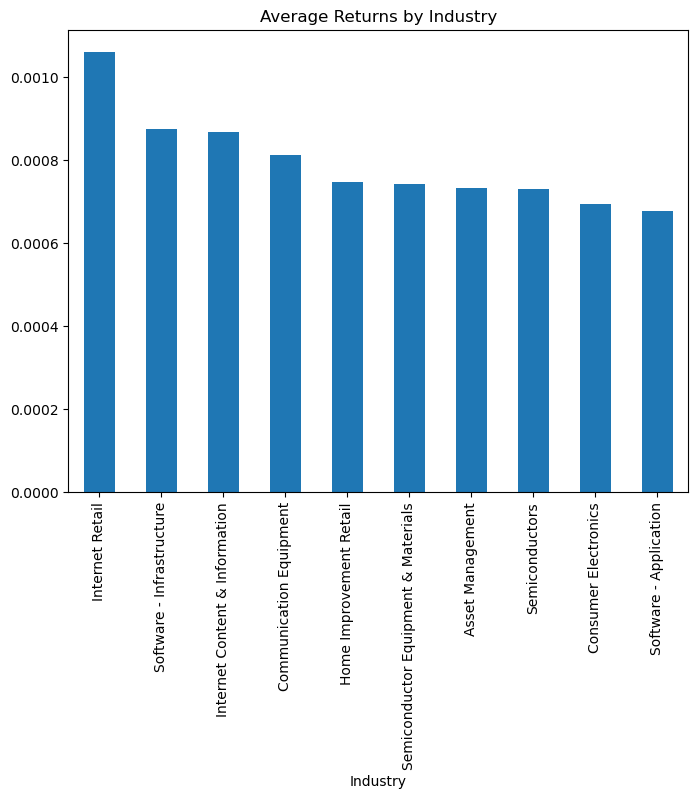

In [44]:
#Industry Returns Comparison
plt.figure(figsize = (8,6))
industry_performance.head(10).plot(kind='bar', title='Average Returns by Industry')
plt.show()

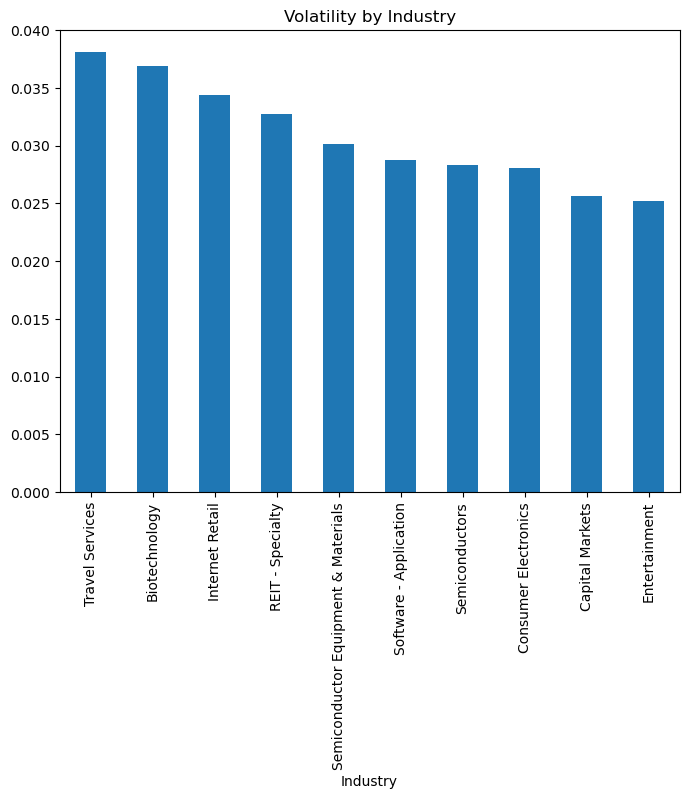

In [45]:
#Industry Volatility Comparison

plt.figure(figsize = (8,6))
industry_risk.head(10).plot(kind='bar', title='Volatility by Industry')
plt.show()

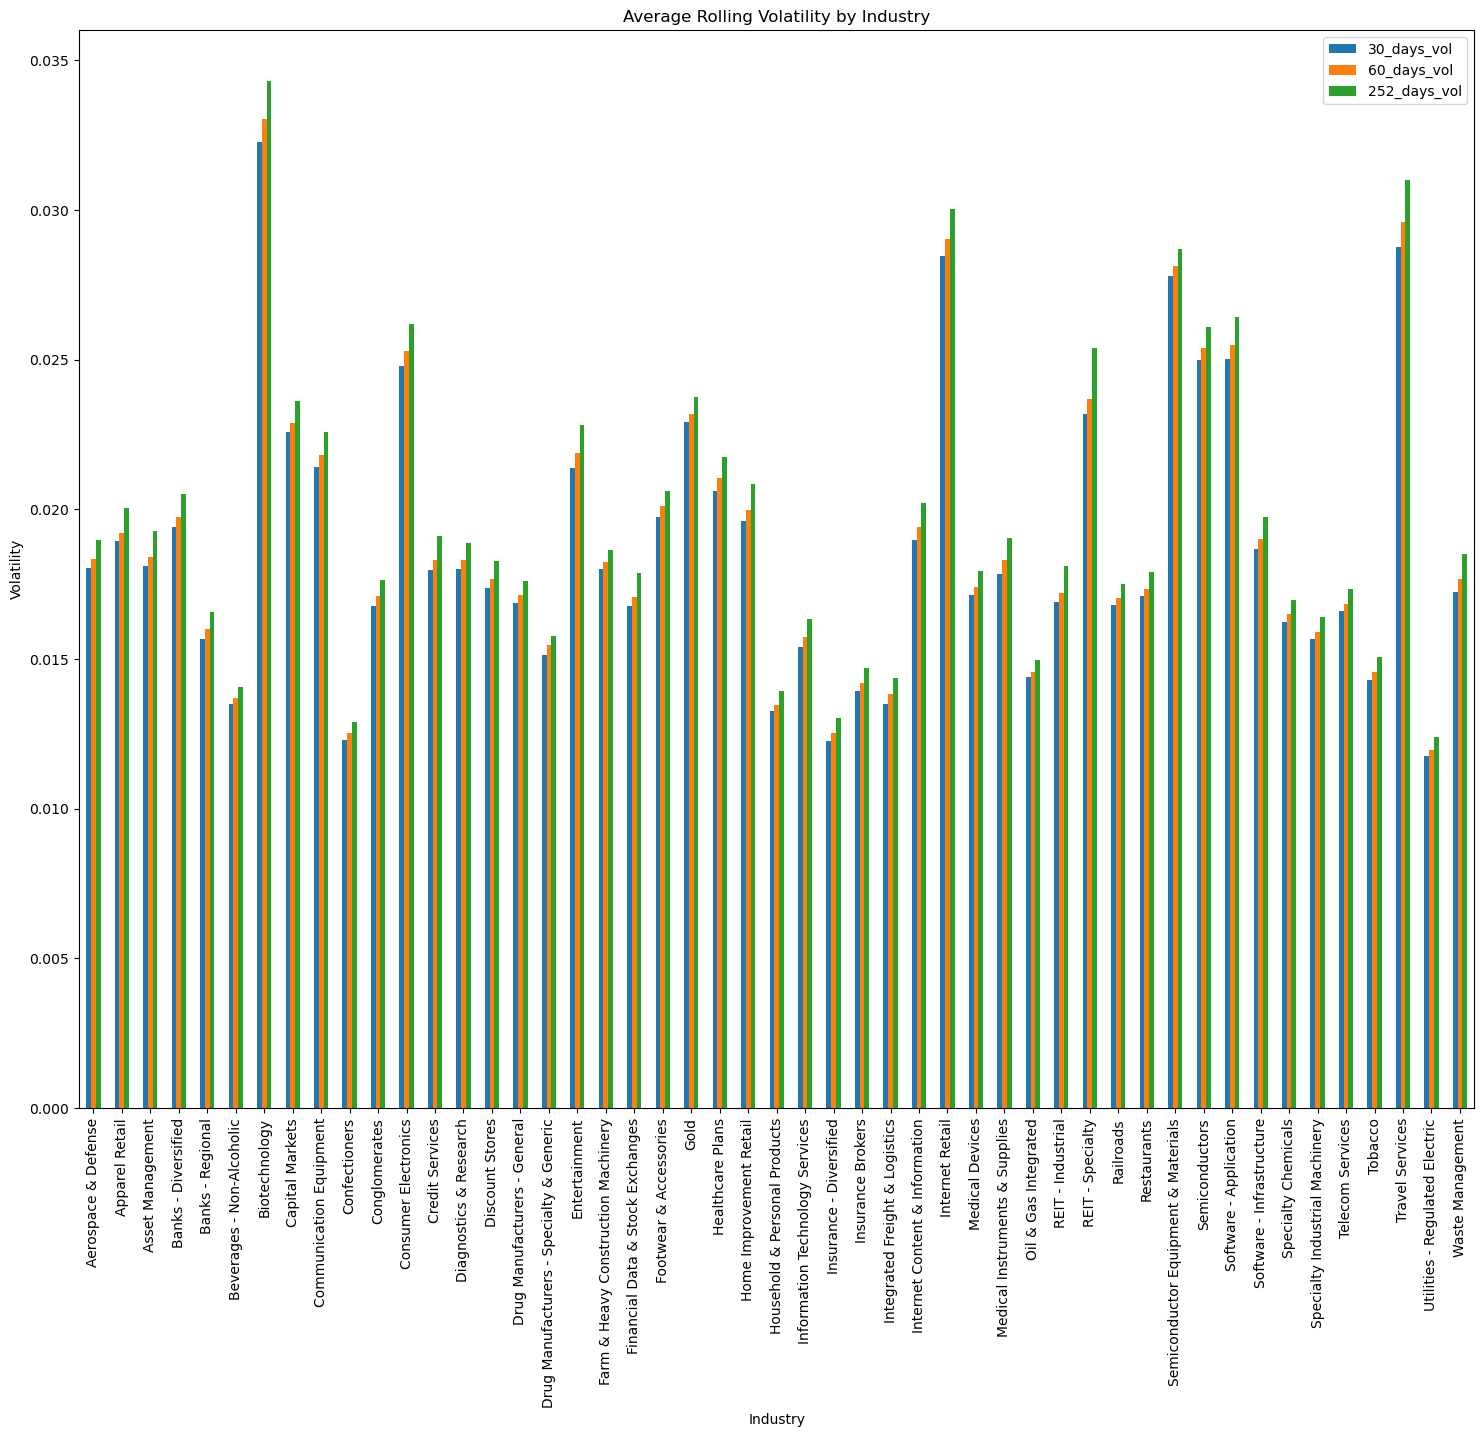

In [46]:
#average rolling volatilty by industry

industry_df = df.dropna(subset=['30_days_vol','60_days_vol','252_days_vol'])
industry_vol = industry_df.groupby('Industry')[['30_days_vol','60_days_vol','252_days_vol']].mean()
industry_vol.plot(kind='bar', figsize=(18,14))
plt.title('Average Rolling Volatility by Industry')
plt.ylabel('Volatility')
plt.show()

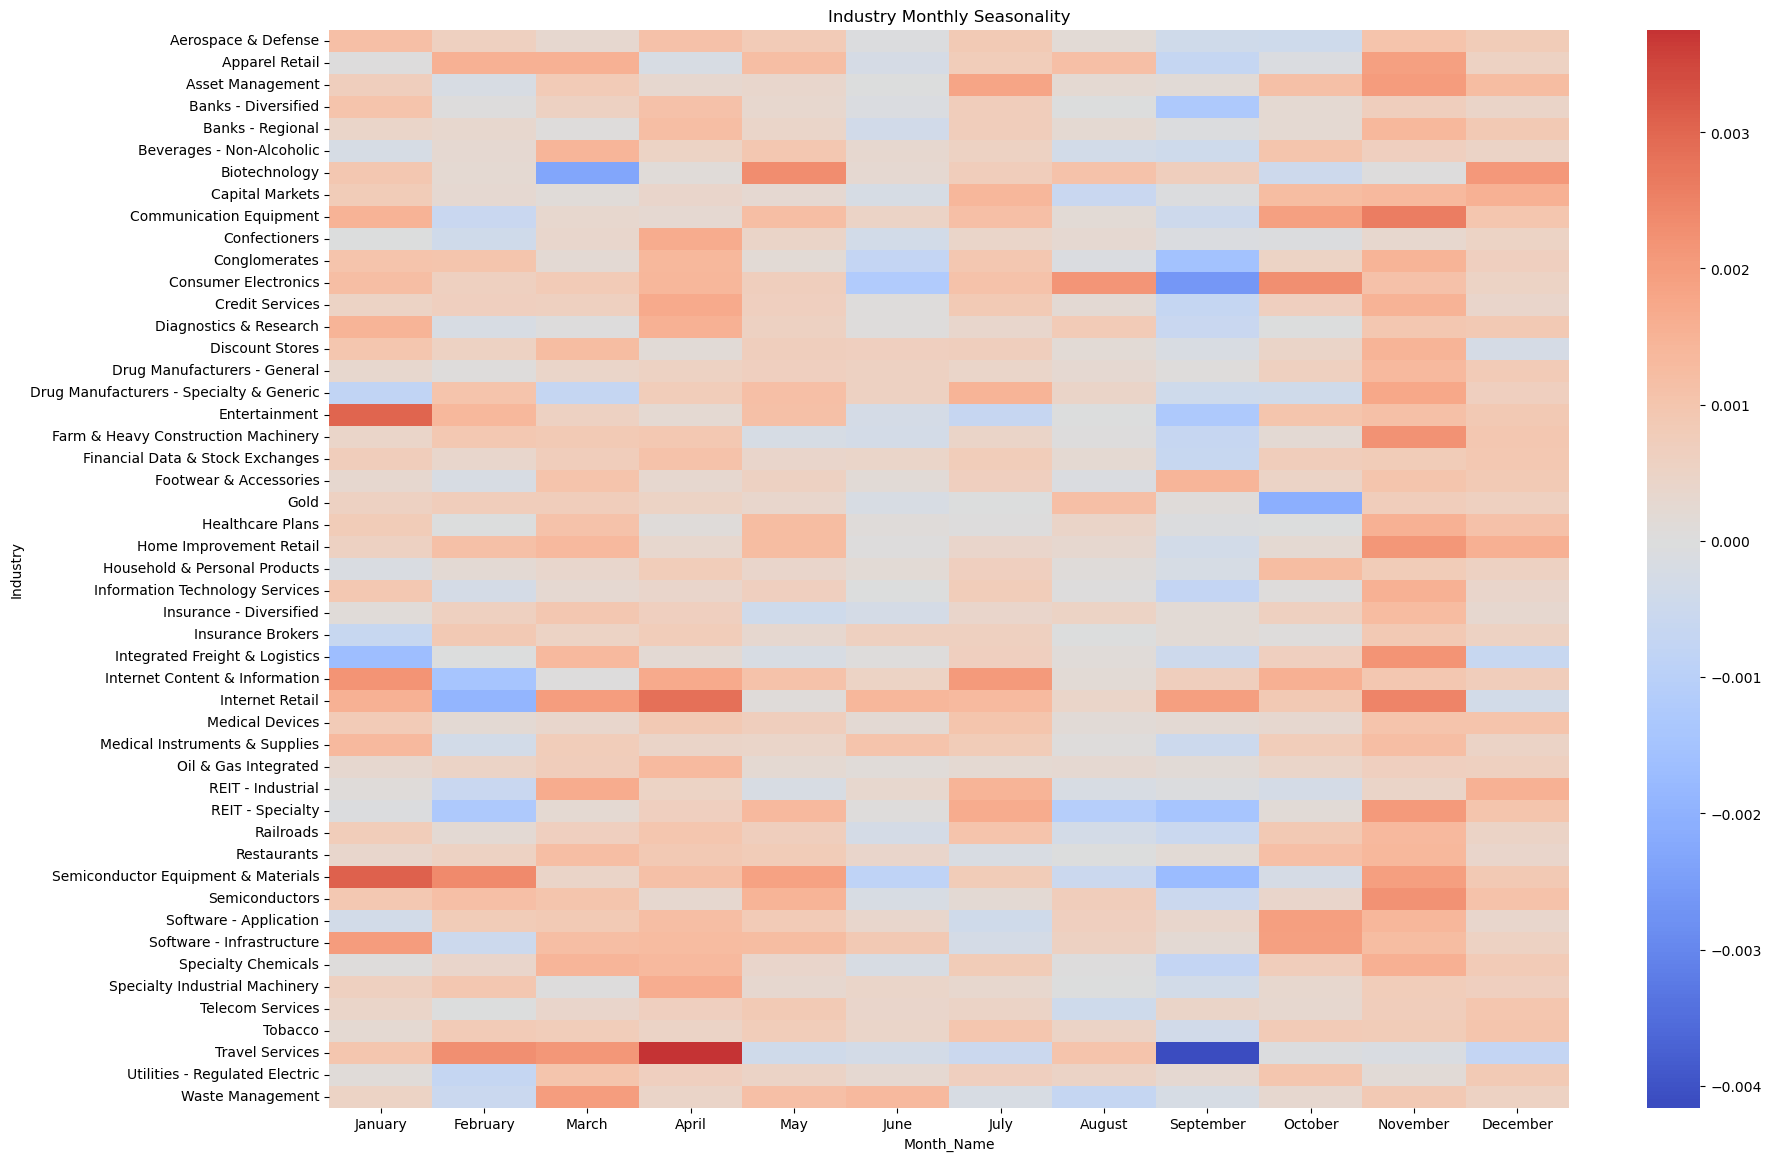

In [47]:
#Heatmap showing industry monthly seasonality

plt.figure(figsize=(20,14))
sns.heatmap(industry_monthly, cmap='coolwarm', center=0)
plt.title("Industry Monthly Seasonality")
plt.show()

Company-Level Summary Statistics

In [48]:
company_summary = df.groupby('Name')['Returns'].agg(
    mean_return='mean',
    volatility='std')

print(company_summary.head())

                     mean_return  volatility
Name                                        
AT&T Inc.               0.000441    0.015506
AbbVie Inc.             0.000722    0.016695
Abbott Laboratories     0.000556    0.016003
Accenture plc           0.000487    0.018733
Adobe Inc.              0.000721    0.030291


In [49]:
#Monthly Seasonality by Company

company_monthly = df.groupby(['Name', 'Month_Name'])['Returns'].mean().unstack()
company_monthly = company_monthly[month_order]

print(company_monthly.head())

Month_Name            January  February     March     April       May  \
Name                                                                    
AT&T Inc.            0.000390 -0.000506  0.000525  0.000879  0.000290   
AbbVie Inc.         -0.000712  0.001884  0.000137  0.000810  0.000036   
Abbott Laboratories  0.000442  0.000483  0.000372  0.001190  0.000581   
Accenture plc       -0.000193 -0.001005  0.000550 -0.000167  0.000550   
Adobe Inc.          -0.000279  0.001410  0.002733  0.002828  0.000306   

Month_Name               June      July    August  September   October  \
Name                                                                     
AT&T Inc.            0.000662  0.000575 -0.000534   0.001057  0.000668   
AbbVie Inc.          0.000367  0.000947  0.000249   0.000537  0.000609   
Abbott Laboratories  0.000446  0.000874 -0.000025   0.000110  0.000784   
Accenture plc        0.000537  0.000699  0.000002   0.000024  0.001371   
Adobe Inc.          -0.000412 -0.000943 -0.0

Yearly Performance by Company

In [50]:
company_yearly = df.groupby(['Name', 'Year'])['Returns'].agg(
    mean_return='mean',
    volatility='std'
)

print(company_yearly.head())

                mean_return  volatility
Name      Year                         
AT&T Inc. 1983    -0.001691    0.006167
          1984     0.001094    0.009979
          1985     0.001158    0.008444
          1986     0.001416    0.011414
          1987    -0.000104    0.018097


Compare companies: which company perform best

In [51]:
company_performance = df.groupby('Name')['Returns'].mean().sort_values(ascending=False)
print(company_performance.head())

Name
Broadcom Inc.              0.001364
NVIDIA Corporation         0.001252
Netflix, Inc.              0.001086
Amazon.com, Inc.           0.001060
Mastercard Incorporated    0.000974
Name: Returns, dtype: float64


Most risky company

In [52]:
company_risk = df.groupby('Name')['Returns'].std().sort_values(ascending=False)
print(company_risk.head())

Name
Regeneron Pharmaceuticals, Inc.    0.039498
Booking Holdings Inc.              0.038101
NVIDIA Corporation                 0.037338
Equinix, Inc.                      0.037121
Netflix, Inc.                      0.034715
Name: Returns, dtype: float64


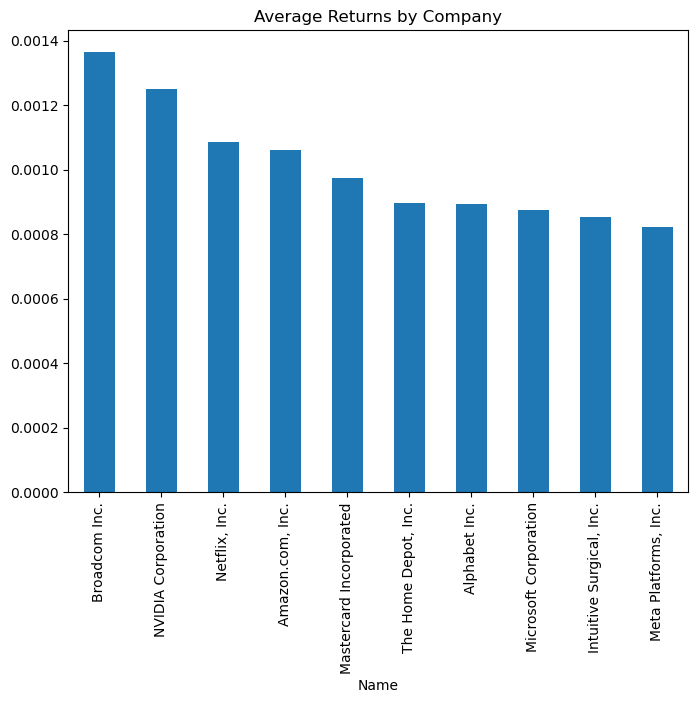

In [53]:
#Company Returns Comparison
plt.figure(figsize = (8,6))
company_performance.head(10).plot(kind='bar', title='Average Returns by Company')
plt.show()

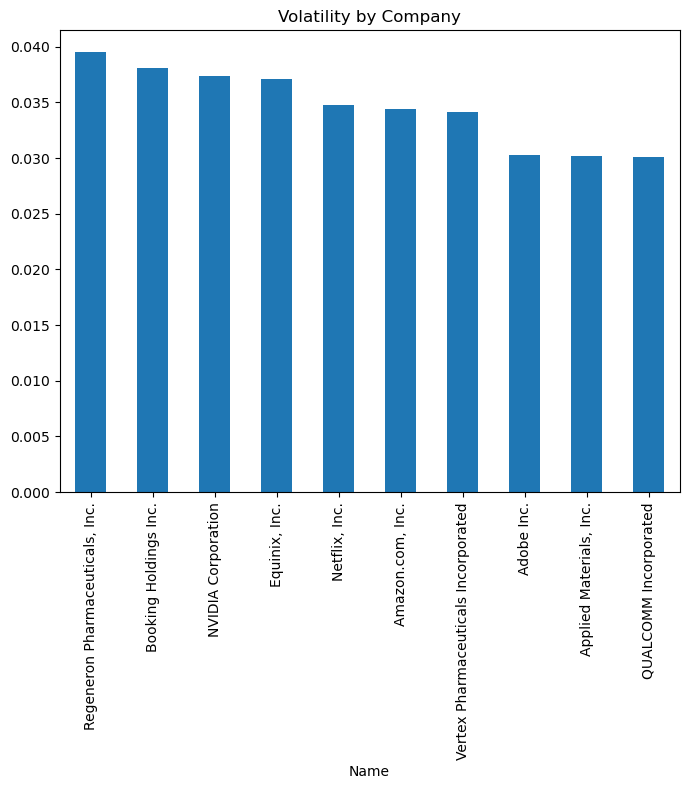

In [54]:
#Company Volatility Comparison

plt.figure(figsize = (8,6))
company_risk.head(10).plot(kind='bar', title='Volatility by Company')
plt.show()